In [ ]:
#Assignment_5_SML_.KNN_REGRSSION
#25070126501
#Amit pawar
#we using a dataset for Sales and Mart data.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression

from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')


### Dataset Description

This section is for documenting the dataset used in this notebook.

**Dataset Name:** (e.g., Sales Mart Data)

**Source:** (e.g., Kaggle, internal database, etc.)

**Overview:** (Briefly describe what the dataset contains and its purpose. For example, 'This dataset contains transactional sales data for various products across different retail outlets.')

**Columns:**
*   **Item_Weight:** (Description of the column, e.g., 'Weight of the product in some units.')
*   **Item_Fat_Content:** (Description of the column, e.g., 'Categorical feature indicating the fat content of the item.')
*   **Item_Visibility:** (Description of the column, e.g., 'The percentage of total display area of all products in a store allocated to the particular product.')
*   **Item_Type:** (Description of the column, e.g., 'The category to which the item belongs.')
*   **Item_MRP:** (Description of the column, e.g., 'Maximum Retail Price of the product.')
*   **Outlet_Establishment_Year:** (Description of the column, e.g., 'The year in which the outlet was established. (Note: This column was dropped during preprocessing due to high VIF).')
*   **Outlet_Size:** (Description of the column, e.g., 'The size of the store in terms of ground area.')
*   **Outlet_Location_Type:** (Description of the column, e.g., 'The type of city in which the outlet is located.')
*   **Outlet_Type:** (Description of the column, e.g., 'The type of outlet.')
*   **Item_Outlet_Sales:** (Description of the column, e.g., 'Sales of the product in a particular store. This is the target variable.')

**Key Characteristics:** (Any important notes, e.g., 'Contains both numerical and categorical features. Missing values were handled for Item_Weight and Outlet_Size.')

### K-Nearest Neighbors (KNN) Regression

KNN Regression is a non-parametric, instance-based learning algorithm used for predicting continuous target variables.

**How it works:**
1.  **Find the K-Nearest Neighbors:** For a new data point that needs a prediction, KNN identifies the 'k' data points in the training dataset that are most similar to it. Similarity is typically measured using distance metrics like Euclidean distance.
2.  **Calculate the Average:** The algorithm then takes the average (or weighted average) of the target values of these 'k' nearest neighbors. This average becomes the predicted value for the new data point.

**Key Parameters:**
*   **`n_neighbors` (k):** The number of nearest neighbors to consider. Choosing an optimal 'k' is crucial; too small might make the model sensitive to noise, while too large might smooth out important local features.
*   **`weights`:** Determines how the neighbors' target values contribute to the prediction. 'uniform' gives equal weight, while 'distance' weights neighbors based on their inverse distance, giving more importance to closer neighbors.
*   **`p`:** The power parameter for the Minkowski distance. When `p=1`, it's Manhattan distance; when `p=2`, it's Euclidean distance.

**Why it's used here:**
KNN Regression is a simple yet effective algorithm, especially when the relationship between features and the target variable is non-linear and complex. It's often a good baseline model and can capture intricate local patterns in the data without making strong assumptions about the underlying data distribution.

In [ ]:
df=pd.read_csv('/content/sales mart.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.shape

(8523, 12)

2 Basic Preprossing
handle missing values


In [ ]:
df=pd.read_csv('/content/sales mart.csv')
#Missing a values treatment
df['Item_Weight'].fillna(df['Item_Weight'].mean(),inplace=True)
df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0],inplace=True)

#df identifier coluns
df.drop(['Item_Identifier','Outlet_Identifier'],axis=1,inplace=True)

#label Encodeing for categrical features
label_cols = df.select_dtypes(include='object').columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])
df.head(10)

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.300000,1,0.016047,4,249.8092,1999,1,0,1,3735.1380
1,5.920000,2,0.019278,14,48.2692,2009,1,2,2,443.4228
2,17.500000,1,0.016760,10,141.6180,1999,1,0,1,2097.2700
3,19.200000,2,0.000000,6,182.0950,1998,1,2,0,732.3800
4,8.930000,1,0.000000,9,53.8614,1987,0,2,1,994.7052
5,10.395000,2,0.000000,0,51.4008,2009,1,2,2,556.6088
6,13.650000,2,0.012741,13,57.6588,1987,0,2,1,343.5528
7,12.857645,1,0.127470,13,107.7622,1985,1,2,3,4022.7636
8,16.200000,2,0.016687,5,96.9726,2002,1,1,1,1076.5986
9,19.200000,2,0.094450,5,187.8214,2007,1,1,1,4710.5350


# Multicollnerity  Check using VIF


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#separate features
X_vif = df.drop('Item_Outlet_Sales', axis=1)

#calculate VIF
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values(by='VIF', ascending=False)

,feature,VIF
5,Outlet_Establishment_Year,39.753411
0,Item_Weight,10.271474
6,Outlet_Size,7.945566
4,Item_MRP,6.136913
7,Outlet_Location_Type,5.828541
1,Item_Fat_Content,5.594651
8,Outlet_Type,4.411612
3,Item_Type,4.011494
2,Item_Visibility,2.760892


In [ ]:
df=df.drop(columns=['Outlet_Establishment_Year'])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#separate features
X_vif = df.drop('Item_Outlet_Sales', axis=1)

#calculate VIF
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values(by='VIF', ascending=False)

,feature,VIF
0,Item_Weight,7.930252
5,Outlet_Size,5.653490
4,Item_MRP,5.451730
6,Outlet_Location_Type,4.870246
1,Item_Fat_Content,4.778592
7,Outlet_Type,4.345999
3,Item_Type,3.658790
2,Item_Visibility,2.657308


In [ ]:
x=df.drop(columns=['Item_Outlet_Sales'])
y=df['Item_Outlet_Sales']


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

#KNN Regrssion Pipeline

In [ ]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsRegressor())
])

#Hyperparameter Turing Using GridSearchCV

In [ ]:
param_grid = {
  'knn__n_neighbors': list(range(1, 21)),
  'knn__weights': ['uniform', 'distance'],
  'knn__p': [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20],
                         'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error')

In [ ]:
grid.best_params_


{'knn__n_neighbors': 20, 'knn__p': 1, 'knn__weights': 'uniform'}

#Model Evaluation

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2F}")
print(f"R2 Score: {r2:.3f}")
print(f"R-squared: {r2}")

RMSE: 1080.26
R2 Score: 0.571
R-squared: 0.5706524009499268


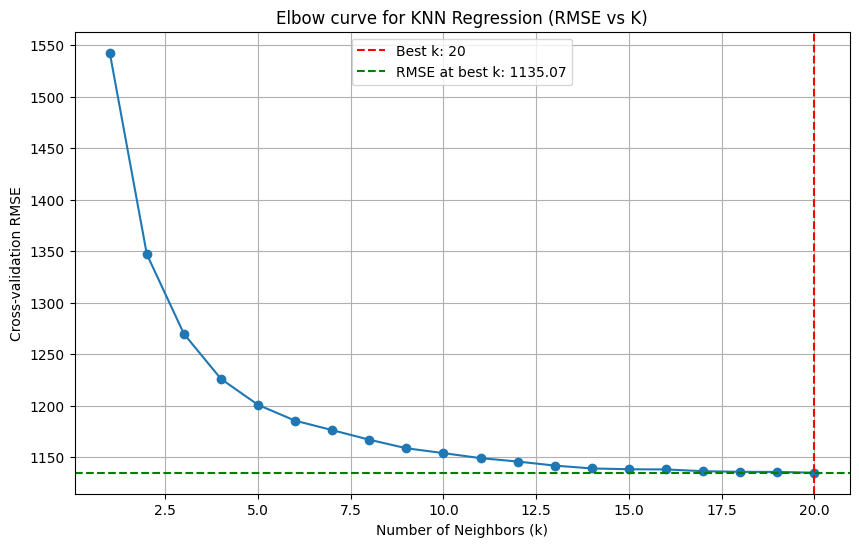

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate rmse_k and best_k for plotting the elbow curve

# Filter cv_results_ to get RMSE values for the best 'weights' and 'p' parameters
results = pd.DataFrame(grid.cv_results_)
best_weights = grid.best_params_['knn__weights']
best_p = grid.best_params_['knn__p']

rmse_k_df = results[
    (results['param_knn__weights'] == best_weights) &
    (results['param_knn__p'] == best_p)
].sort_values(by='param_knn__n_neighbors')

# Convert negative mean squared error to RMSE
rmse_k_values = np.sqrt(-rmse_k_df['mean_test_score'])
n_neighbors_for_plot = rmse_k_df['param_knn__n_neighbors']

# Create a Series for plotting RMSE vs k
rmse_k = pd.Series(rmse_k_values.values, index=n_neighbors_for_plot.values)

# Get the best k from grid.best_params_
best_k = grid.best_params_['knn__n_neighbors']

plt.figure(figsize=(10, 6))
plt.plot(rmse_k.index, rmse_k.values, marker='o')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k: {best_k}')
plt.axhline(y=rmse_k.loc[best_k], color='g', linestyle='--', label=f'RMSE at best k: {rmse_k.loc[best_k]:.2f}')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-validation RMSE")
plt.title("Elbow curve for KNN Regression (RMSE vs K)")
plt.legend()
plt.grid(True)
plt.show()